In [29]:
import sys

from datasets import load_dataset
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os

from PIL import Image
import pyarrow as pa




meta_data = load_dataset("marco-schouten/hidden-objects")


In [2]:
from adlcv_project.data import HiddenObjectsDatasetStreaming

dataset = HiddenObjectsDatasetStreaming("../data/")

Original number of boxes: 16
Detected number of heatmap regions / modes: 3
  Mode 1: peak=(479, 167), area=5088, bbox=(443, 130, 511, 205)
  Mode 2: peak=(297, 318), area=4961, bbox=(273, 292, 325, 418)
  Mode 3: peak=(461, 414), area=10807, bbox=(412, 371, 490, 511)


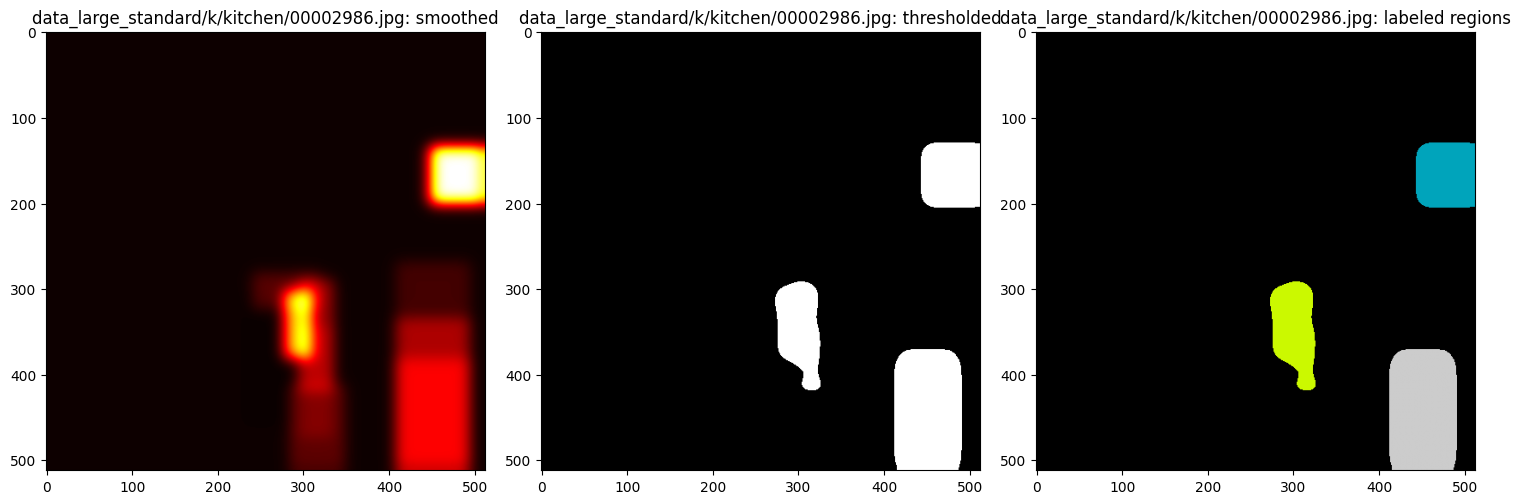

Trying to load image from: C:\Users\Jacob pc\vscode_projects\ADLCV_PROJECT\data\data_large_standard\k\kitchen\00002986.jpg


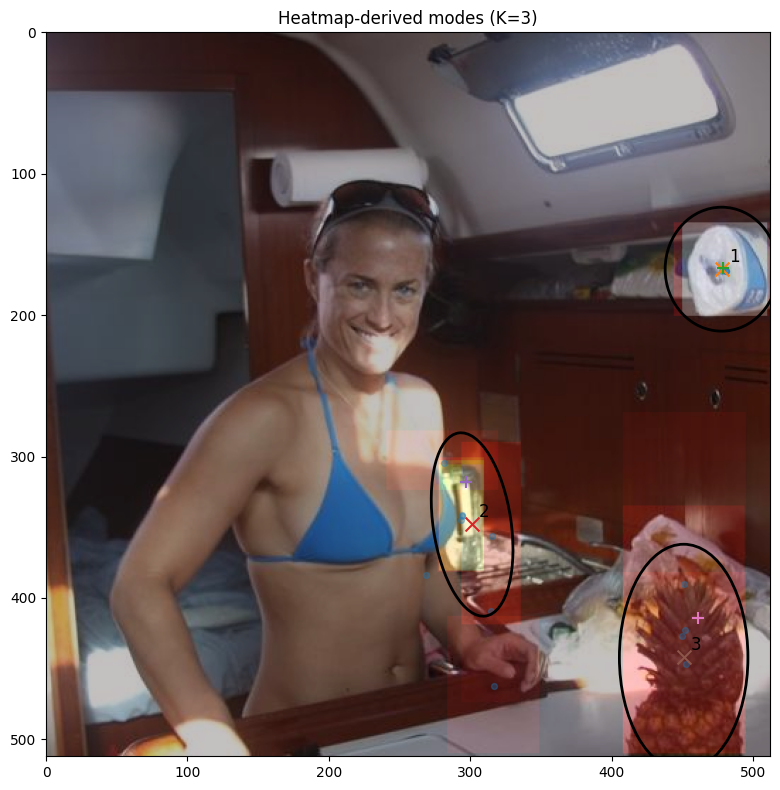

Original number of boxes: 62
Detected number of heatmap regions / modes: 2
  Mode 1: peak=(349, 190), area=33708, bbox=(304, 63, 419, 386)
  Mode 2: peak=(255, 271), area=5422, bbox=(199, 224, 294, 301)


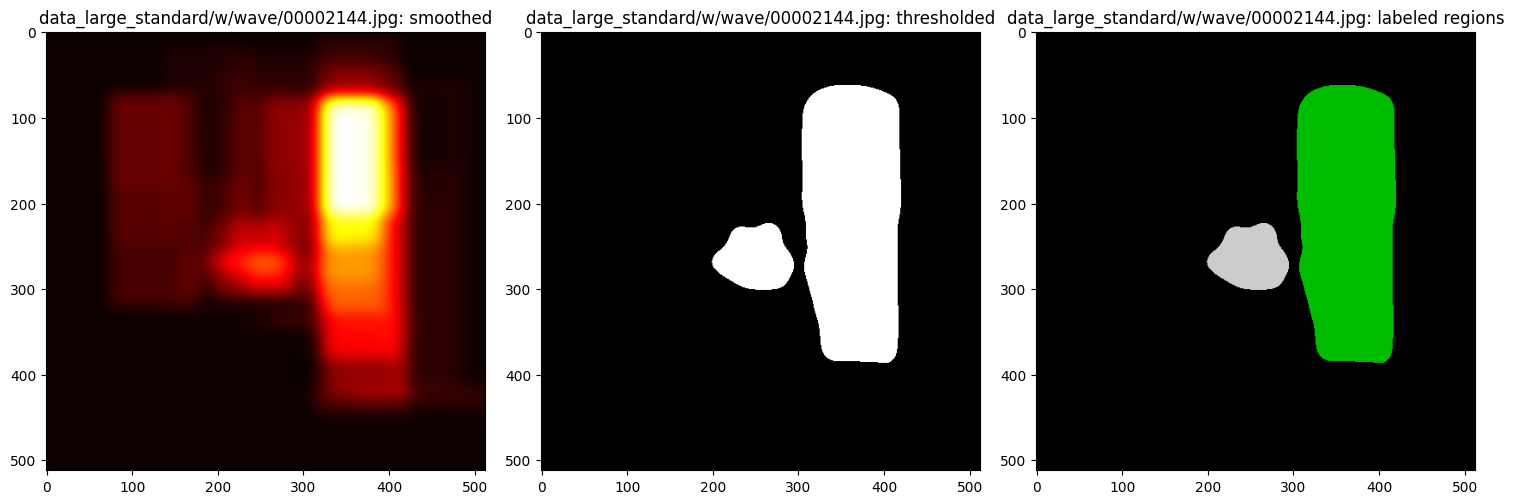

Trying to load image from: C:\Users\Jacob pc\vscode_projects\ADLCV_PROJECT\data\data_large_standard\w\wave\00002144.jpg


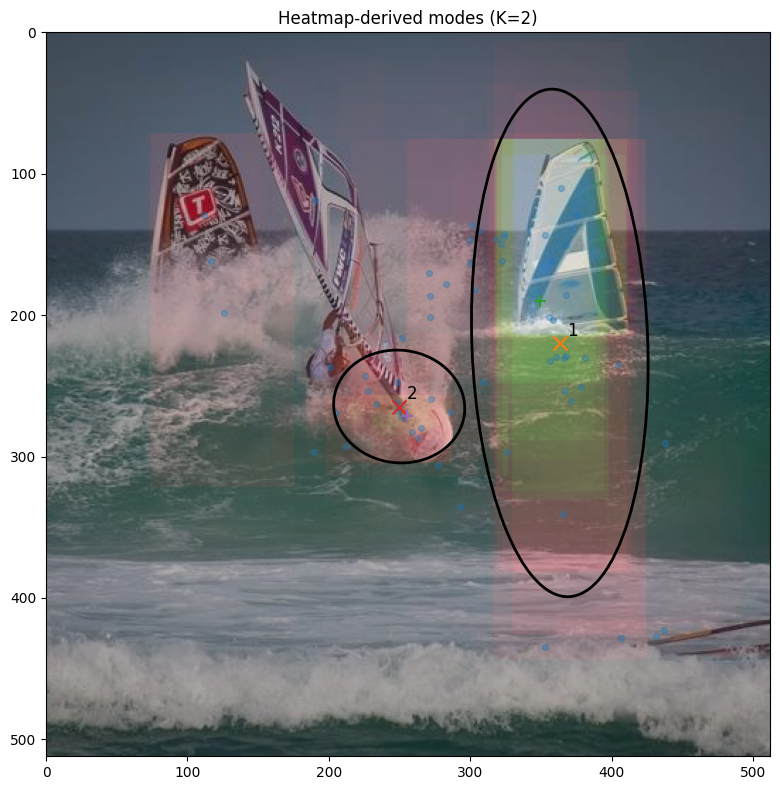

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from PIL import Image

from scipy.ndimage import gaussian_filter, label, maximum_filter


# ============================================================
# 1. FILTER HELPERS
# ============================================================

def get_filtered_data(bg_path, fg_class, label=1):
    return dataset.hf_data.filter(
        lambda x: (x["bg_path"] == bg_path)
        and (x["fg_class"] == fg_class)
        and (x["label"] == label)
    )


def center_crop_512(img, img_size):
    w, h = img.size
    left = (w - img_size) // 2
    top = (h - img_size) // 2
    return img.crop((left, top, left + img_size, top + img_size))


def resolve_image_path(bg_path, dataset_root=None):
    if os.path.isabs(bg_path):
        candidate = bg_path
    elif dataset_root is not None:
        candidate = os.path.join(dataset_root, bg_path)
    else:
        candidate = bg_path

    return os.path.normpath(candidate)


def load_image(bg_path, img_size, dataset_root=None, verbose=False):
    resolved_path = resolve_image_path(bg_path, dataset_root=dataset_root)

    if verbose:
        print(f"Trying to load image from: {resolved_path}")

    if not os.path.exists(resolved_path):
        raise FileNotFoundError(
            f"Could not find image.\n"
            f"bg_path from dataset: {bg_path}\n"
            f"Resolved path used: {resolved_path}\n"
            f"Current working directory: {os.getcwd()}\n"
            f"Set dataset_root to the folder that contains the dataset."
        )

    img = Image.open(resolved_path).convert("RGB")
    img = center_crop_512(img, img_size)
    return np.array(img)


# ============================================================
# 2. HEATMAP CONSTRUCTION
# ============================================================

def get_heatmap(rows, img_size, score_transform="neg", normalize=False):
    rows = list(rows)
    heatmap = np.zeros((img_size, img_size), dtype=np.float64)

    scores = None
    if score_transform == "pos_shift":
        scores = np.asarray(
            [row["image_reward_score"] for row in rows],
            dtype=np.float64
        )

    for row in rows:
        x, y, w, h = row["bbox"]

        x = int(np.clip(x * img_size, 0, img_size - 1))
        y = int(np.clip(y * img_size, 0, img_size - 1))
        w = int(np.clip(w * img_size, 1, img_size))
        h = int(np.clip(h * img_size, 1, img_size))

        x2 = min(x + w, img_size)
        y2 = min(y + h, img_size)

        score = row["image_reward_score"]

        if score_transform == "neg":
            value = -score
        elif score_transform == "pos_shift":
            value = score - scores.min() + 1e-6
        elif score_transform == "constant":
            value = 1.0
        else:
            raise ValueError(f"Unknown score_transform: {score_transform}")

        heatmap[y:y2, x:x2] += value

    if normalize:
        total = heatmap.sum()
        if total > 0:
            heatmap = heatmap / total

    return heatmap


# ============================================================
# 3. EXTRACT FEATURES FROM BBOXES
# ============================================================

def extract_bbox_features(rows, img_size, feature_mode="xy", score_mode="neg_shift"):
    rows = list(rows)

    X = []
    raw_scores = []

    for row in rows:
        x, y, w, h = row["bbox"]

        x *= img_size
        y *= img_size
        w *= img_size
        h *= img_size

        cx = x + w / 2.0
        cy = y + h / 2.0

        if feature_mode == "xy":
            feat = [cx, cy]
        elif feature_mode == "xywh":
            feat = [cx, cy, w, h]
        else:
            raise ValueError(f"Unknown feature_mode: {feature_mode}")

        X.append(feat)
        raw_scores.append(row["image_reward_score"])

    X = np.asarray(X, dtype=np.float64)
    raw_scores = np.asarray(raw_scores, dtype=np.float64)

    if score_mode == "neg_shift":
        weights = -raw_scores
        weights = weights - weights.min() + 1e-6
    elif score_mode == "shift":
        weights = raw_scores - raw_scores.min() + 1e-6
    elif score_mode == "constant":
        weights = np.ones_like(raw_scores, dtype=np.float64)
    else:
        raise ValueError(f"Unknown score_mode: {score_mode}")

    return X, weights


# ============================================================
# 4. HEATMAP REGION / PEAK DETECTION
# ============================================================

def smooth_heatmap(heatmap, sigma=12.0):
    return gaussian_filter(heatmap, sigma=sigma)


def detect_heatmap_regions(
    heatmap,
    sigma=12.0,
    threshold_rel=0.35,
    min_region_size=150,
    peak_min_distance=25
):
    """
    Detect semantic placement regions from a heatmap.

    Steps:
    - smooth the heatmap
    - threshold at threshold_rel * max
    - find connected components
    - find one representative peak per component

    Returns
    -------
    result : dict
        {
            "smoothed": ...,
            "binary_mask": ...,
            "labeled": ...,
            "num_regions": ...,
            "regions": [
                {
                    "label": int,
                    "peak_xy": (x, y),
                    "peak_value": float,
                    "coords": np.ndarray of shape (N, 2),  # (y, x)
                    "bbox": (x_min, y_min, x_max, y_max),
                    "area": int,
                },
                ...
            ]
        }
    """
    smoothed = smooth_heatmap(heatmap, sigma=sigma)

    max_val = smoothed.max()
    if max_val <= 0:
        return {
            "smoothed": smoothed,
            "binary_mask": np.zeros_like(smoothed, dtype=bool),
            "labeled": np.zeros_like(smoothed, dtype=np.int32),
            "num_regions": 0,
            "regions": [],
        }

    threshold = threshold_rel * max_val
    binary_mask = smoothed >= threshold

    labeled, num_regions = label(binary_mask)

    # local maxima candidates
    local_max = smoothed == maximum_filter(smoothed, size=peak_min_distance)

    regions = []

    for region_id in range(1, num_regions + 1):
        coords = np.argwhere(labeled == region_id)  # (y, x)

        if len(coords) < min_region_size:
            continue

        ys = coords[:, 0]
        xs = coords[:, 1]

        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()

        region_mask = (labeled == region_id)
        region_local_max = local_max & region_mask

        peak_coords = np.argwhere(region_local_max)

        if len(peak_coords) == 0:
            # fallback: use max inside region
            values = smoothed[ys, xs]
            best_idx = np.argmax(values)
            peak_y, peak_x = ys[best_idx], xs[best_idx]
        else:
            peak_vals = smoothed[peak_coords[:, 0], peak_coords[:, 1]]
            best_idx = np.argmax(peak_vals)
            peak_y, peak_x = peak_coords[best_idx]

        regions.append({
            "label": region_id,
            "peak_xy": (int(peak_x), int(peak_y)),
            "peak_value": float(smoothed[peak_y, peak_x]),
            "coords": coords,
            "bbox": (int(x_min), int(y_min), int(x_max), int(y_max)),
            "area": int(len(coords)),
        })

    # relabel region count after filtering tiny regions
    regions = sorted(regions, key=lambda r: r["peak_value"], reverse=True)

    return {
        "smoothed": smoothed,
        "binary_mask": binary_mask,
        "labeled": labeled,
        "num_regions": len(regions),
        "regions": regions,
    }


# ============================================================
# 5. FIT ONE GAUSSIAN PER REGION
# ============================================================

def fit_gaussians_to_regions(region_result, min_cov=20.0):
    """
    Fit one Gaussian (mean + covariance) to each detected heatmap region.

    Returns
    -------
    gaussians : list of dict
        {
            "mean": np.ndarray shape (2,),
            "cov": np.ndarray shape (2, 2),
            "peak_xy": (x, y),
            "bbox": (...),
            "area": int
        }
    """
    gaussians = []

    for region in region_result["regions"]:
        coords = region["coords"]  # (y, x)
        ys = coords[:, 0].astype(np.float64)
        xs = coords[:, 1].astype(np.float64)

        points = np.stack([xs, ys], axis=1)

        mean = points.mean(axis=0)

        if len(points) >= 2:
            cov = np.cov(points.T)
        else:
            cov = np.eye(2) * min_cov

        if cov.shape == ():
            cov = np.eye(2) * min_cov

        if cov.shape == (2, 2):
            cov = cov + np.eye(2) * min_cov

        gaussians.append({
            "mean": mean,
            "cov": cov,
            "peak_xy": region["peak_xy"],
            "bbox": region["bbox"],
            "area": region["area"],
        })

    return gaussians


# ============================================================
# 6. PLOTTING
# ============================================================

def plot_gaussian_ellipse(mean, cov, ax, n_std=1.5, **kwargs):
    if cov.shape != (2, 2):
        return

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    vals = np.maximum(vals, 1e-9)

    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )
    ax.add_patch(ellipse)


def plot_region_modes_on_image(
    image,
    heatmap,
    smoothed_heatmap,
    region_result,
    gaussians,
    X=None,
    img_size=512,
    title="Heatmap region modes",
    heatmap_alpha=0.30,
    show_points=True,
    point_alpha=0.35,
    ellipse_n_std=1.5
):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image)

    if heatmap is not None:
        ax.imshow(heatmap, cmap="hot", alpha=heatmap_alpha, origin="upper")

    if show_points and X is not None and X.shape[1] >= 2:
        ax.scatter(X[:, 0], X[:, 1], s=18, alpha=point_alpha)

    for i, g in enumerate(gaussians):
        mean = g["mean"]
        cov = g["cov"]
        peak_x, peak_y = g["peak_xy"]

        plot_gaussian_ellipse(
            mean,
            cov,
            ax,
            n_std=ellipse_n_std,
            linewidth=2
        )
        ax.scatter(mean[0], mean[1], s=100, marker="x")
        ax.scatter(peak_x, peak_y, s=80, marker="+")
        ax.text(mean[0] + 5, mean[1] - 5, f"{i+1}", fontsize=12)

    ax.set_xlim(0, img_size)
    ax.set_ylim(img_size, 0)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_region_debug(region_result, title_prefix="Heatmap region detection"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(region_result["smoothed"], cmap="hot", origin="upper")
    axes[0].set_title(f"{title_prefix}: smoothed")

    axes[1].imshow(region_result["binary_mask"], cmap="gray", origin="upper")
    axes[1].set_title(f"{title_prefix}: thresholded")

    axes[2].imshow(region_result["labeled"], cmap="nipy_spectral", origin="upper")
    axes[2].set_title(f"{title_prefix}: labeled regions")

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. MAIN PIPELINE
# ============================================================

def run_heatmap_mode_experiment(
    rows,
    img_size=512,
    bg_path=None,
    dataset_root=None,
    feature_mode="xy",
    score_mode="constant",
    heatmap_score_transform="neg",
    sigma=12.0,
    threshold_rel=0.35,
    min_region_size=150,
    peak_min_distance=25,
    heatmap_alpha=0.30,
    show_points=True,
    ellipse_n_std=1.5,
    verbose=True,
    show_debug=True
):
    rows = list(rows)

    if len(rows) == 0:
        raise ValueError("No rows found for this scene/class.")

    if bg_path is None:
        if "bg_path" in rows[0]:
            bg_path = rows[0]["bg_path"]
        else:
            raise ValueError("bg_path was not provided and could not be inferred from rows.")

    heatmap = get_heatmap(
        rows,
        img_size=img_size,
        score_transform=heatmap_score_transform,
        normalize=False
    )

    X, weights = extract_bbox_features(
        rows,
        img_size=img_size,
        feature_mode=feature_mode,
        score_mode=score_mode
    )

    region_result = detect_heatmap_regions(
        heatmap,
        sigma=sigma,
        threshold_rel=threshold_rel,
        min_region_size=min_region_size,
        peak_min_distance=peak_min_distance
    )

    gaussians = fit_gaussians_to_regions(region_result, min_cov=20.0)

    print(f"Original number of boxes: {len(X)}")
    print(f"Detected number of heatmap regions / modes: {region_result['num_regions']}")

    for i, region in enumerate(region_result["regions"], start=1):
        print(
            f"  Mode {i}: peak={region['peak_xy']}, "
            f"area={region['area']}, bbox={region['bbox']}"
        )

    if show_debug:
        plot_region_debug(region_result, title_prefix=f"{bg_path}")

    image = load_image(
        bg_path=bg_path,
        img_size=img_size,
        dataset_root=dataset_root,
        verbose=verbose
    )

    plot_region_modes_on_image(
        image=image,
        heatmap=heatmap,
        smoothed_heatmap=region_result["smoothed"],
        region_result=region_result,
        gaussians=gaussians,
        X=X,
        img_size=img_size,
        title=f"Heatmap-derived modes (K={region_result['num_regions']})",
        heatmap_alpha=heatmap_alpha,
        show_points=show_points,
        ellipse_n_std=ellipse_n_std
    )

    return {
        "heatmap": heatmap,
        "X": X,
        "weights": weights,
        "region_result": region_result,
        "gaussians": gaussians,
        "selected_k": region_result["num_regions"],
        "bg_path": bg_path,
        "resolved_image_path": resolve_image_path(bg_path, dataset_root),
    }


# ============================================================
# 8. EXAMPLE USAGE
# ============================================================

DATASET_ROOT = "C:/Users/Jacob pc/vscode_projects/ADLCV_PROJECT/data"


# Example 1
rows_ds = get_filtered_data(
    bg_path="data_large_standard/k/kitchen/00002986.jpg",
    fg_class="bottle",
    label=1
)
rows = list(rows_ds)

result_kitchen = run_heatmap_mode_experiment(
    rows=rows,
    img_size=512,
    bg_path="data_large_standard/k/kitchen/00002986.jpg",
    dataset_root=DATASET_ROOT,
    feature_mode="xy",
    score_mode="constant",
    heatmap_score_transform="neg",
    sigma=8.0,
    threshold_rel=0.25,
    min_region_size=120,
    peak_min_distance=25,
    heatmap_alpha=0.25,
    show_points=True,
    ellipse_n_std=2,
    verbose=True,
    show_debug=True
)


# Example 2
rows_ds = get_filtered_data(
    bg_path="data_large_standard/w/wave/00002144.jpg",
    fg_class="surfboard",
    label=1
)
rows = list(rows_ds)

result_wave = run_heatmap_mode_experiment(
    rows=rows,
    img_size=512,
    bg_path="data_large_standard/w/wave/00002144.jpg",
    dataset_root=DATASET_ROOT,
    feature_mode="xy",
    score_mode="constant",
    heatmap_score_transform="neg",
    sigma=8.0,
    threshold_rel=0.25,
    min_region_size=120,
    peak_min_distance=25,
    heatmap_alpha=0.25,
    show_points=True,
    ellipse_n_std=2,
    verbose=True,
    show_debug=True
)